Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited's disclosed scale, not actual company records.

# Complete forecasting analysis: Falak Extreme Basmati Rice 5 kg

MGT-353 Portfolio Milestone 1 · Mohammad Omer Farooq · Facilitator: Faisal Jalal

**Decision:** How many 5 kg packs should Matco plan to supply over the next 12 weeks, and how much should it commit now versus keep flexible?

This notebook contains the dataset, demand diagnosis, seven forecasting approaches, error metrics, common-origin holdout validation, multiple regression, a forward forecast, and operational stress tests. It runs in Google Colab without a data upload. Select **Runtime → Run all**. The CSV is frozen and embedded; all results below were executed before delivery.

**Periods:** train 2 Oct 2023–29 Jun 2026 (144 weeks); holdout 6 Jul–21 Sep 2026 (12 weeks). Forward planning origin: after the week ending 27 Sep 2026; week starts 28 Sep–14 Dec 2026, ending 20 Dec. This is an academic planning snapshot, not a live forecast as of submission.

**AI disclosure:** AI generated the dataset, code, figures and narrative. Automated checks are documented. Student understanding and manual verification are not asserted on the student's behalf. The separate AI Use Log records the prompts and limitations.

In [1]:
import io, hashlib, json, statistics
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
try:
    from IPython.display import display, Markdown
except ImportError:
    def display(x): print(x.to_string() if hasattr(x, "to_string") else x)
    Markdown = str

LABEL = "Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited's disclosed scale, not actual company records."
EXPECTED_SHA256 = "b94ac87db74da82ec4360aef446667e8a1478c87497c226f32728fae85d79a1d"
CSV_TEXT = '"Week_Start_Date","Product_or_Category","Market_Channel","Actual_Demand","Historical_Forecast","Price","Promo_Flag","Promo_Depth","Event_Flag","Event_Name","Distribution_Points","Stockout_Flag","Exceptional_Event","Data_Split","Dataset_Label"\n"2023-10-02","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5407,5000,2400,0,0,0,"",1021,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2023-10-09","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5015,5115,2400,0,0,0,"",1022,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2023-10-16","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6458,5540,2400,1,0.1,0,"",1014,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2023-10-23","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4822,5098,2400,0,0,0,"",1008,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2023-10-30","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5437,5077,2400,0,0,0,"",1028,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2023-11-06","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6526,5602,2400,1,0.12,0,"",1034,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2023-11-13","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5056,5225,2400,0,0,0,"",1024,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2023-11-20","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4477,5182,2400,0,0,0,"",1031,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2023-11-27","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5429,5225,2400,0,0,0,"",1026,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2023-12-04","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",8006,5622,2400,1,0.1,0,"",1016,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2023-12-11","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5581,5160,2400,0,0,0,"",1017,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2023-12-18","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4396,5170,2400,0,0,0,"",1004,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2023-12-25","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5417,5107,2400,0,0,0,"",1008,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-01-01","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5240,5130,2400,0,0,0,"",991,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-01-08","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6097,5046,2400,0,0,0,"",988,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-01-15","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6754,5434,2400,1,0.12,0,"",975,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-01-22","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4656,4965,2400,0,0,0,"",973,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-01-29","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5237,4954,2400,0,0,0,"",978,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-02-05","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6526,5375,2400,1,0.12,0,"",973,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-02-12","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4825,4949,2400,0,0,0,"",981,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-02-19","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4825,4986,2500,0,0,0,"",988,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-02-26","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5261,4957,2500,0,0,0,"",986,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-03-04","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",9044,5831,2500,1,0.12,1,"Ramadan stocking",1016,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-03-11","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6293,5595,2500,0,0,1,"Ramadan stocking; Ramadan",1015,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-03-18","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4982,5583,2500,0,0,1,"Ramadan",1012,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-03-25","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5034,5559,2500,0,0,1,"Ramadan",1015,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-04-01","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5977,5568,2500,0,0,1,"Ramadan; Eid-ul-Fitr",1055,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-04-08","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5504,5780,2500,0,0,1,"Eid-ul-Fitr",1037,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-04-15","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",7231,5570,2500,1,0.12,0,"",1091,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-04-22","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5202,5418,2500,0,0,0,"",1056,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-04-29","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4779,5237,2500,0,0,0,"",1049,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-05-06","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6066,5610,2500,1,0.1,0,"",1038,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-05-13","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5499,5134,2500,0,0,0,"",1040,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-05-20","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5131,5137,2500,0,0,0,"",1039,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-05-27","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4775,5126,2500,0,0,0,"",1010,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-06-03","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5943,5376,2500,1,0.08,0,"",1036,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-06-10","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5556,5611,2500,0,0,1,"Eid-ul-Adha",1018,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-06-17","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5235,5509,2500,0,0,1,"Eid-ul-Adha",1002,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-06-24","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5009,4926,2500,0,0,0,"",998,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-07-01","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5126,4904,2500,0,0,0,"",998,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-07-08","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4409,4903,2600,0,0,0,"",1020,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-07-15","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6686,5348,2600,1,0.12,0,"",1002,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-07-22","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4320,4865,2600,0,0,0,"",1009,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-07-29","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4468,4900,2600,0,0,0,"",1017,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-08-05","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4875,5336,2600,1,0.1,0,"",1023,0,"Illustrative competitor discount campaign","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-08-12","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4287,4973,2600,0,0,0,"",1031,0,"Illustrative competitor discount campaign","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-08-19","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5676,5016,2600,0,0,0,"",1037,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-08-26","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5543,5050,2600,0,0,0,"",1029,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-09-02","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5986,5418,2600,1,0.1,0,"",1045,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-09-09","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5184,5101,2600,0,0,0,"",1060,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-09-16","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5454,5182,2600,0,0,0,"",1072,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-09-23","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4799,5248,2600,0,0,0,"",1059,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-09-30","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5358,5193,2600,0,0,0,"",1079,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-10-07","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6222,5301,2600,0,0,0,"",1099,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-10-14","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",7222,5841,2600,1,0.12,0,"",1079,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-10-21","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5214,5320,2600,0,0,0,"",1062,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-10-28","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5458,5246,2600,0,0,0,"",1073,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-11-04","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5335,5735,2600,1,0.05,0,"",1062,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-11-11","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4779,5266,2600,0,0,0,"",1026,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-11-18","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5223,5097,2600,0,0,0,"",1021,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-11-25","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4941,5081,2550,0,0,0,"",1026,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-12-02","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",7721,5556,2550,1,0.12,0,"",1020,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-12-09","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5179,5123,2550,0,0,0,"",1014,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-12-16","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5240,5101,2550,0,0,0,"",1011,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-12-23","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5399,5093,2550,0,0,0,"",1017,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2024-12-30","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5258,5130,2550,0,0,0,"",1053,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-01-06","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5143,5317,2550,0,0,0,"",1043,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-01-13","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6114,5693,2550,1,0.12,0,"",1024,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-01-20","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5163,5180,2550,0,0,0,"",1041,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-01-27","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4597,5269,2550,0,0,0,"",1056,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-02-03","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6075,5775,2550,1,0.05,0,"",1054,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-02-10","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5157,5339,2550,0,0,0,"",1070,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-02-17","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6029,5962,2550,0,0,1,"Ramadan stocking",1083,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-02-24","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6460,6034,2550,0,0,1,"Ramadan stocking",1083,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-03-03","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",7510,6471,2550,1,0.08,1,"Ramadan stocking; Ramadan",1088,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-03-10","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5817,6057,2550,0,0,1,"Ramadan",1096,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-03-17","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5263,6098,2550,0,0,1,"Ramadan",1092,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-03-24","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6535,6071,2550,0,0,1,"Eid-ul-Fitr",1072,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-03-31","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6183,5955,2550,0,0,1,"Eid-ul-Fitr",1086,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-04-07","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4790,5478,2550,0,0,0,"",1089,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-04-14","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",7488,5926,2650,1,0.12,0,"",1083,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-04-21","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4991,5388,2650,0,0,0,"",1063,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-04-28","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4989,5281,2650,0,0,0,"",1059,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-05-05","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6120,5675,2650,1,0.08,0,"",1057,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-05-12","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6765,5237,2650,0,0,0,"",1046,0,"Illustrative retailer display campaign","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-05-19","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5766,5175,2650,0,0,0,"",1054,0,"Illustrative retailer display campaign","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-05-26","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5349,5728,2650,0,0,1,"Eid-ul-Adha",1055,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-06-02","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",8791,6141,2650,1,0.05,1,"Eid-ul-Adha",1046,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-06-09","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5405,5668,2650,0,0,1,"Eid-ul-Adha",1042,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-06-16","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5269,5127,2650,0,0,0,"",1053,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-06-23","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4999,5174,2650,0,0,0,"",1061,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-06-30","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5246,5208,2650,0,0,0,"",1083,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-07-07","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5263,5310,2650,0,0,0,"",1077,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-07-14","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",8135,5698,2650,1,0.1,0,"",1104,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-07-21","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5465,5405,2650,0,0,0,"",1113,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-07-28","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5625,5446,2650,0,0,0,"",1102,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-08-04","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6873,5821,2650,1,0.12,0,"",1114,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-08-11","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5866,5447,2650,0,0,0,"",1116,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-08-18","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5168,5456,2650,0,0,0,"",1105,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-08-25","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5833,5403,2650,0,0,0,"",1128,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-09-01","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",7200,5959,2750,1,0.05,0,"",1118,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-09-08","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5729,5411,2750,0,0,0,"",1092,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-09-15","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5870,5289,2750,0,0,0,"",1102,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-09-22","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5720,5342,2750,0,0,0,"",1093,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-09-29","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4820,5304,2750,0,0,0,"",1088,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-10-06","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6649,5286,2750,0,0,0,"",1074,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-10-13","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5874,5643,2750,1,0.05,0,"",1072,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-10-20","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5350,5223,2750,0,0,0,"",1066,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-10-27","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5570,5202,2750,0,0,0,"",1082,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-11-03","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6840,5712,2750,1,0.12,0,"",1055,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-11-10","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5589,5166,2750,0,0,0,"",1060,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-11-17","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5854,5200,2750,0,0,0,"",1095,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-11-24","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5305,5382,2750,0,0,0,"",1077,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-12-01","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",7305,5728,2750,1,0.08,0,"",1074,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-12-08","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5307,5299,2750,0,0,0,"",1072,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-12-15","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5573,5299,2750,0,0,0,"",1090,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-12-22","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5645,5398,2750,0,0,0,"",1093,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2025-12-29","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5305,5422,2750,0,0,0,"",1131,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-01-05","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5756,5620,2750,0,0,0,"",1137,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-01-12","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6280,6111,2750,1,0.05,0,"",1133,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-01-19","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5610,5647,2800,0,0,0,"",1121,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-01-26","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5307,5565,2800,0,0,0,"",1140,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-02-02","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",7601,6119,2800,1,0.1,0,"",1154,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-02-09","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6406,6316,2800,0,0,1,"Ramadan stocking",1124,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-02-16","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",7041,6157,2800,0,0,1,"Ramadan stocking; Ramadan",1138,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-02-23","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5687,6238,2800,0,0,1,"Ramadan",1130,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-03-02","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",7453,6648,2800,1,0.1,1,"Ramadan",1107,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-03-09","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5805,6073,2800,0,0,1,"Ramadan; Eid-ul-Fitr",1100,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-03-16","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6801,6036,2800,0,0,1,"Eid-ul-Fitr",1097,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-03-23","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5213,6020,2800,0,0,1,"Eid-ul-Fitr",1076,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-03-30","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",3974,5367,2800,0,0,0,"",1093,1,"Illustrative packaging supply delay","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-04-06","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4003,5449,2800,0,0,0,"",1092,1,"Illustrative packaging supply delay","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-04-13","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5860,5877,2800,1,0.08,0,"",1086,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-04-20","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5228,5408,2800,0,0,0,"",1095,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-04-27","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5145,5448,2800,0,0,0,"",1097,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-05-04","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",7313,5889,2800,1,0.08,0,"",1102,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-05-11","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5880,5472,2800,0,0,0,"",1095,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-05-18","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6012,5974,2800,0,0,1,"Eid-ul-Adha",1110,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-05-25","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6199,6048,2800,0,0,1,"Eid-ul-Adha",1120,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-06-01","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6877,5983,2800,1,0.1,0,"",1127,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-06-08","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5447,5567,2865,0,0,0,"",1131,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-06-15","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4877,5540,2865,0,0,0,"",1148,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-06-22","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5575,5615,2865,0,0,0,"",1146,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-06-29","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5856,5598,2865,0,0,0,"",1159,0,"","Train","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-07-06","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5229,5653,2865,0,0,0,"",1153,0,"","Holdout","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-07-13","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6997,6066,2865,1,0.05,0,"",1168,0,"","Holdout","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-07-20","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5349,5682,2865,0,0,0,"",1163,0,"","Holdout","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-07-27","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5430,5651,2865,0,0,0,"",1164,0,"","Holdout","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-08-03","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",6448,6102,2865,1,0.08,0,"",1137,0,"","Holdout","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-08-10","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4787,5513,2865,0,0,0,"",1136,0,"","Holdout","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-08-17","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5294,5504,2865,0,0,0,"",1136,0,"","Holdout","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-08-24","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4083,5500,2865,0,0,0,"",1134,1,"Illustrative transport disruption","Holdout","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-08-31","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5597,5927,2865,1,0.08,0,"",1128,1,"Illustrative transport disruption","Holdout","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-09-07","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",4766,5457,2865,0,0,0,"",1094,0,"","Holdout","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-09-14","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5375,5292,2865,0,0,0,"",1107,0,"","Holdout","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n"2026-09-21","Falak Extreme Basmati Rice 5 kg","Pakistan domestic retail",5421,5355,2865,0,0,0,"",1106,0,"","Holdout","Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited\'s disclosed scale, not actual company records."\n'
assert hashlib.sha256(CSV_TEXT.encode("utf-8")).hexdigest() == EXPECTED_SHA256
df = pd.read_csv(io.StringIO(CSV_TEXT), parse_dates=["Week_Start_Date"])
train_df = df.iloc[:144].copy()
test_df = df.iloc[144:].copy()
assert len(df) == 156 and len(train_df) == 144 and len(test_df) == 12
assert df.Week_Start_Date.is_monotonic_increasing
assert df.Week_Start_Date.diff().dropna().eq(pd.Timedelta(days=7)).all()
assert df.Week_Start_Date.is_unique
assert train_df.Data_Split.eq("Train").all() and test_df.Data_Split.eq("Holdout").all()
assert df.Actual_Demand.gt(0).all()
print("Frozen CSV hash verified; 156 consecutive weeks; 144 training / 12 holdout.")
display(df.head())

Frozen CSV hash verified; 156 consecutive weeks; 144 training / 12 holdout.
  Week_Start_Date              Product_or_Category            Market_Channel  Actual_Demand  Historical_Forecast  Price  Promo_Flag  Promo_Depth  Event_Flag Event_Name  Distribution_Points  Stockout_Flag Exceptional_Event Data_Split                                                                                                                                                        Dataset_Label
0      2023-10-02  Falak Extreme Basmati Rice 5 kg  Pakistan domestic retail           5407                 5000   2400           0          0.0           0        NaN                 1021              0               NaN      Train  Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Matco Foods Limited's disclosed scale, not actual company records.
1      2023-10-09  Falak Extreme Basmati Rice 5 kg  Pakistan domestic retail           5015                 5115   2400         

## Descriptive statistics

Demand is measured in **5 kg packs per week**. Standard deviation uses the sample formula (n−1), matching Excel STDEV.S. CV = sample standard deviation ÷ mean. It measures relative sales dispersion, not forecast error or the safety stock required. Do not turn the entire historical standard deviation directly into safety stock because promotions, events and coverage changes contribute to it.

In [2]:
def describe_sales(part):
    y = part.Actual_Demand.astype(float)
    return {"Weeks": len(y), "Total packs": y.sum(), "Mean packs/week": y.mean(), "Median packs/week": y.median(), "Sample standard deviation": y.std(ddof=1), "Minimum packs/week": y.min(), "Maximum packs/week": y.max(), "Range packs/week": y.max()-y.min(), "CV (%)": 100*y.std(ddof=1)/y.mean()}
summary = pd.DataFrame({"Full history (156 weeks)":describe_sales(df), "Training (144 weeks)":describe_sales(train_df), "Holdout (12 weeks; descriptive only)":describe_sales(test_df)})
# Independent verification uses Python statistics, without pandas formulas.
for part in [df, train_df, test_df]:
    values = part.Actual_Demand.tolist()
    assert np.isclose(part.Actual_Demand.mean(), sum(values)/len(values))
    assert np.isclose(part.Actual_Demand.median(), statistics.median(values))
    assert np.isclose(part.Actual_Demand.std(ddof=1), statistics.stdev(values))
display(summary.round(2))
print(f"Full-history mean volume: {df.Actual_Demand.mean()*5/1000:.2f} tonnes/week.")

                           Full history (156 weeks)  Training (144 weeks)  Holdout (12 weeks; descriptive only)
Weeks                                        156.00                144.00                                 12.00
Total packs                               887799.00             823023.00                              64776.00
Mean packs/week                             5691.02               5715.44                               5398.00
Median packs/week                           5450.50               5482.00                               5362.00
Sample standard deviation                    900.98                910.18                                753.46
Minimum packs/week                          3974.00               3974.00                               4083.00
Maximum packs/week                          9044.00               9044.00                               6997.00
Range packs/week                            5070.00               5070.00                               

## Demand over time with business events

The upper plot uses only training observations for demand diagnosis. Gold markers identify promotions. Pale gold bands mark Ramadan/Eid event windows. The trailing 13-week average is a descriptive smoother, not a forward forecast. The lower plot includes the held-out actuals for retrospective context, with the evaluation block shaded and explicitly labelled. All company disruptions are illustrative synthetic scenarios.

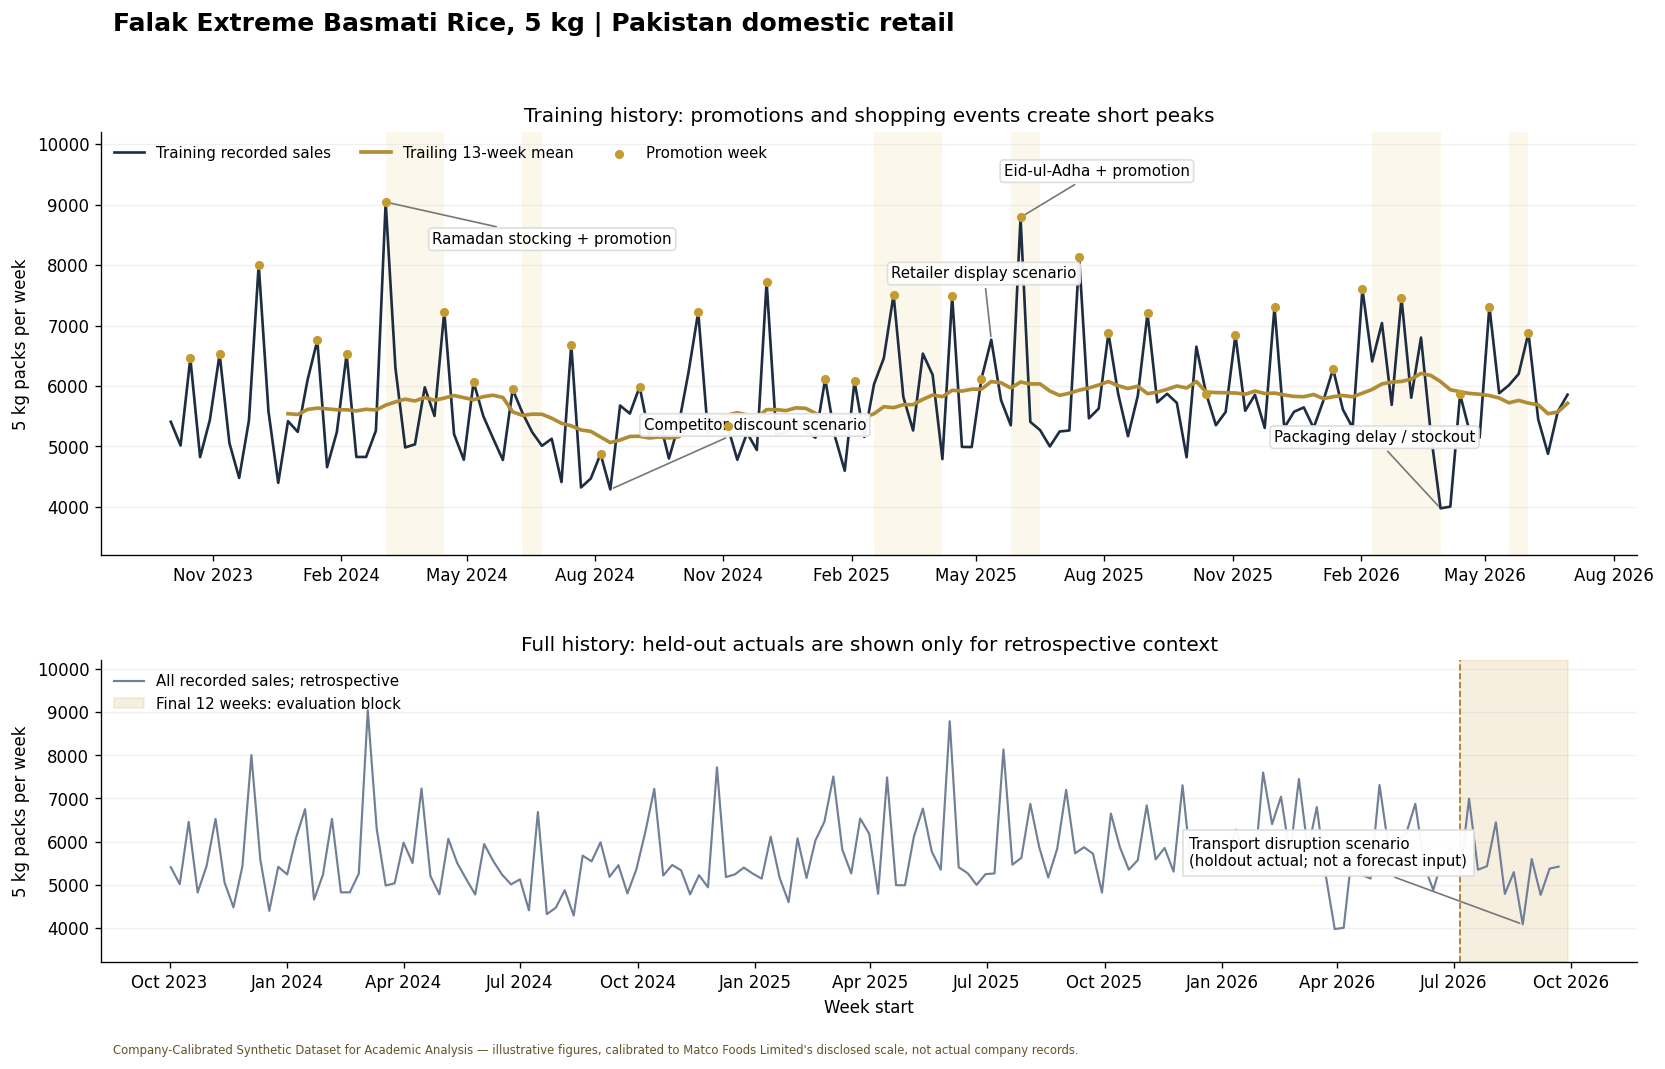

In [3]:
plt.rcParams.update({"font.size":10, "axes.spines.top":False, "axes.spines.right":False})
fig, axes = plt.subplots(2,1,figsize=(14,9),gridspec_kw={"height_ratios":[1.4,1]})
ax = axes[0]
ax.plot(train_df.Week_Start_Date, train_df.Actual_Demand, color="#1E2D42", lw=1.6, label="Training recorded sales")
ax.plot(train_df.Week_Start_Date, train_df.Actual_Demand.rolling(13,min_periods=13).mean(), color="#B08C35", lw=2.2, label="Trailing 13-week mean")
promos=train_df[train_df.Promo_Flag.eq(1)]
ax.scatter(promos.Week_Start_Date,promos.Actual_Demand,s=20,color="#C49A32",zorder=4,label="Promotion week")
for week in train_df.loc[train_df.Event_Flag.eq(1),"Week_Start_Date"]:
    ax.axvspan(week,week+pd.Timedelta(days=7),color="#E6C96B",alpha=.13,lw=0)
annotations=[("2024-03-04","Ramadan stocking + promotion",28,-25),("2024-08-12","Competitor discount scenario",20,36),("2025-05-12","Retailer display scenario",-60,37),("2025-06-02","Eid-ul-Adha + promotion",-10,25),("2026-03-30","Packaging delay / stockout",-100,40)]
for date,text,dx,dy in annotations:
    row=train_df.loc[train_df.Week_Start_Date.eq(pd.Timestamp(date))].iloc[0]
    ax.annotate(text,xy=(row.Week_Start_Date,row.Actual_Demand),xytext=(dx,dy),textcoords="offset points",fontsize=9,ha="left",arrowprops={"arrowstyle":"-","color":"#777777"},bbox={"boxstyle":"round,pad=.25","facecolor":"white","edgecolor":"#DDDDDD","alpha":.95})
ax.set(title="Training history: promotions and shopping events create short peaks",ylabel="5 kg packs per week",ylim=(3200,10200))
ax.legend(loc="upper left",ncol=3,frameon=False,fontsize=9)
ax.grid(axis="y",alpha=.17)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3));ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2=axes[1]
ax2.plot(df.Week_Start_Date,df.Actual_Demand,color="#718097",lw=1.3,label="All recorded sales; retrospective")
ax2.axvspan(test_df.Week_Start_Date.min(),test_df.Week_Start_Date.max()+pd.Timedelta(days=7),color="#C49A32",alpha=.15,label="Final 12 weeks: evaluation block")
ax2.axvline(test_df.Week_Start_Date.min(),color="#9C7725",ls="--",lw=1)
row=test_df.loc[test_df.Week_Start_Date.eq(pd.Timestamp("2026-08-24"))].iloc[0]
ax2.annotate("Transport disruption scenario\n(holdout actual; not a forecast input)",xy=(row.Week_Start_Date,row.Actual_Demand),xytext=(-200,35),textcoords="offset points",fontsize=9,arrowprops={"arrowstyle":"-","color":"#777777"},bbox={"facecolor":"white","edgecolor":"#DDDDDD","alpha":.95})
ax2.set(title="Full history: held-out actuals are shown only for retrospective context",ylabel="5 kg packs per week",xlabel="Week start",ylim=(3200,10200))
ax2.legend(loc="upper left",frameon=False,fontsize=9)
ax2.grid(axis="y",alpha=.17);ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3));ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.suptitle("Falak Extreme Basmati Rice, 5 kg | Pakistan domestic retail",fontsize=15,fontweight="bold",x=.07,ha="left")
fig.text(.07,.015,LABEL,fontsize=7,color="#665329")
fig.tight_layout(rect=(0,.035,1,.95),h_pad=3)
fig.savefig("MGT353_Forecasting_M1_MohammadOmerFarooq_Matco_Demand_Pattern.png",dpi=180,bbox_inches="tight")
plt.show()

## Calendar, promotion and availability comparisons

Compare promotion and event combinations separately to avoid presenting their overlap as a promotion-only effect. These are unadjusted averages, not causal estimates. Price, time, distribution points, discount depth, exceptional events and noise may differ across groups. Four training weeks combine promotion and events, so that group is particularly small.

In [4]:
groups=(train_df.groupby(["Promo_Flag","Event_Flag"]).Actual_Demand.agg(["count","mean"]).reset_index())
groups["Description"]=["Neither promotion nor event" if p==0 and e==0 else "Event only" if p==0 else "Promotion only" if e==0 else "Promotion + event" for p,e in zip(groups.Promo_Flag,groups.Event_Flag)]
baseline=groups.loc[groups.Promo_Flag.eq(0)&groups.Event_Flag.eq(0),"mean"].iloc[0]
groups["Difference vs neither (%)"]=(groups["mean"]/baseline-1)*100
display(groups[["Description","count","mean","Difference vs neither (%)"]].round(2))
print("Differences are unadjusted associations within synthetic training data.")
display(df.loc[df.Exceptional_Event.notna(),["Week_Start_Date","Actual_Demand","Promo_Flag","Stockout_Flag","Exceptional_Event","Data_Split"]])
trend_comparison={"First 26 training weeks":train_df.iloc[:26].Actual_Demand.mean(),"Last 26 training weeks":train_df.iloc[-26:].Actual_Demand.mean()}
display(pd.Series(trend_comparison,name="Mean packs/week").round(2))
print("This rough level comparison is not seasonally adjusted and does not isolate underlying growth.")

                   Description  count     mean  Difference vs neither (%)
0  Neither promotion nor event     88  5251.69                       0.00
1                   Event only     23  5860.26                      11.59
2               Promotion only     29  6665.17                      26.91
3            Promotion + event      4  8199.50                      56.13
Differences are unadjusted associations within synthetic training data.
    Week_Start_Date  Actual_Demand  Promo_Flag  Stockout_Flag                          Exceptional_Event Data_Split
44       2024-08-05           4875           1              0  Illustrative competitor discount campaign      Train
45       2024-08-12           4287           0              0  Illustrative competitor discount campaign      Train
84       2025-05-12           6765           0              0     Illustrative retailer display campaign      Train
85       2025-05-19           5766           0              0     Illustrative retailer displa

## Demand Pattern Diagnosis (100–150 words)

In [5]:
diagnosis = (f"Across the 144 training weeks, recorded sales average {train_df.Actual_Demand.mean():,.0f} five-kilogram packs, with a median of {train_df.Actual_Demand.median():,.0f} and a coefficient of variation of {100*train_df.Actual_Demand.std(ddof=1)/train_df.Actual_Demand.mean():.1f}%. The series has a relatively stable core level with modest upward drift, interrupted by promotional peaks and calendar-linked Ramadan/Eid shopping bursts. Event timing moves between years, so a fixed 52-week seasonal repeat may misalign the peaks. The packaging-delay scenario suppresses sales and should not be interpreted as a permanent decline in customer demand. Exceptional observations return towards ordinary levels, with no clear sustained structural break. A naive forecast provides the benchmark; moving averages and simple exponential smoothing suit ordinary weeks but cannot anticipate events. A damped trend model and calendar-aware driver model are useful candidates. Model comparisons must use the same unseen 12-week holdout, and simulated driver associations cannot establish real-world causation.")
assert 100 <= len(diagnosis.split()) <= 150
display(Markdown(diagnosis))
print("Diagnosis word count:",len(diagnosis.split()))

Across the 144 training weeks, recorded sales average 5,715 five-kilogram packs, with a median of 5,482 and a coefficient of variation of 15.9%. The series has a relatively stable core level with modest upward drift, interrupted by promotional peaks and calendar-linked Ramadan/Eid shopping bursts. Event timing moves between years, so a fixed 52-week seasonal repeat may misalign the peaks. The packaging-delay scenario suppresses sales and should not be interpreted as a permanent decline in customer demand. Exceptional observations return towards ordinary levels, with no clear sustained structural break. A naive forecast provides the benchmark; moving averages and simple exponential smoothing suit ordinary weeks but cannot anticipate events. A damped trend model and calendar-aware driver model are useful candidates. Model comparisons must use the same unseen 12-week holdout, and simulated driver associations cannot establish real-world causation.
Diagnosis word count: 135


## Forecasting candidates and assumptions

| Method | Why include it | Limitation to test |
|---|---|---|
| Naive | Essential simple benchmark | Carries the latest level into every future week |
| Four-week moving average | Smooths short-term noise | Lags changes and does not anticipate promotions |
| SES, alpha 0.3 and 0.6 | Compare smoother and faster level responses | No explicit event or trend component |
| Damped Holt trend | Allows restrained continuation of observed drift | Events remain unexplained |
| 52-week seasonal naive | Additional seasonal benchmark | Ramadan/Eid shift in the Gregorian calendar |
| Calendar-aware regression | Connect planned price, promotions and events to demand | Future coverage and stockouts cannot be taken from realised holdout outcomes |

The candidate definitions below are frozen before holdout scoring. The provisional choice uses the common holdout; it is not a guarantee of future performance. Further tuning must use training-only validation, and a fresh holdout would be needed for another unbiased selection test.

## AI use and verification log

The user requested the next milestone step after accepting the fixed dataset and its documented assumptions. AI generated the analysis code, chart, interpretation and Excel formulas. Verification included the original CSV hash, calendar ordering, partition counts, independent mean/median/sample-standard-deviation calculations, grouped counts and the diagnosis word count. The previous synthesis prompt remains in the Excel Prompt sheet. The original dataset was not regenerated or altered. The 13-week average is a descriptive smoother, and full-history summaries must not be reported as out-of-sample forecast accuracy.

In [6]:
results={"label":LABEL,"summary":summary.to_dict(),"groups":groups.to_dict(orient="records"),"diagnosis":diagnosis,"diagnosis_word_count":len(diagnosis.split()),"first26":trend_comparison["First 26 training weeks"],"last26":trend_comparison["Last 26 training weeks"],"csv_sha256":EXPECTED_SHA256}
Path("MGT353_Forecasting_M1_MohammadOmerFarooq_Matco_Analysis_Results.json").write_text(json.dumps(results,indent=2),encoding="utf-8")
print("All descriptive-statistics checks passed. Forecasting follows below.")

All descriptive-statistics checks passed. Forecasting follows below.


## Forecast error fundamentals: Section 7

Use **Error = Actual − Forecast** in every calculation. A positive error means the plan was too low; a negative error means it was too high. MAD/MAE is the average absolute miss in packs. MAPE averages each week's absolute percentage error; zero or near-zero actuals make it undefined or unstable (none occur here). RMSE penalizes large misses. WAPE divides total absolute error by total actual volume. Bias/MFE is the mean signed error; RSFE is its cumulative sum. Tracking Signal = RSFE/MAD, using the same observation window.

The supplied Historical_Forecast represents successive weekly planning forecasts. Score it separately from the common-origin 12-week competition. On the 144-week training period: MAD **546.69 packs**, MAPE **8.98%**, RMSE **780.92 packs**, WAPE **9.57%**, Bias **+255.17 packs/week**, RSFE **+36,744 packs**, Tracking Signal **+67.21**. This indicates sustained underforecasting in the illustrative prior plans. Investigate the plan's level and promotional/calendar assumptions. The large RMSE relative to MAD shows that some misses are much larger than ordinary ones.

The ±4 tracking-signal band is an **illustrative review trigger**, not a statistical control limit or a Matco policy. Signals depend on the number of accumulated weeks: the 144-week historical signal and 12-week model signal are not directly comparable. A flag triggers investigation, not automatic rejection.

## Common-origin forecasting: Section 8

Training: **2 October 2023–29 June 2026**, 144 weeks. Holdout: **6 July–21 September 2026**, 12 weeks. The June 29 observation covers the week through July 5. No holdout actuals enter any model fit or recursive forecast.

- Naive repeats the last training actual. Seasonal naive repeats the corresponding week 52 weeks earlier.
- Four-week SMA recursively appends forecasts, not actuals.
- SES uses alpha 0.3 and 0.6, initialized with the first training actual; multi-step forecasts equal the final level.
- Damped Holt uses a predeclared 160-candidate grid, training one-step MSE after eight warm-up residuals, first-observation initialization and zero initial trend.
- Event-adjusted damped Holt estimates a training-only association using intercept, time and Event_Flag, subtracts the event effect before fitting Holt, and adds the calendar-known effect back to forecasts. The known holdout calendar has no Ramadan/Eid weeks. Fixed 52-week Holt-Winters is not forced because Ramadan/Eid moves on the Gregorian calendar and three years provide few cycles; an explicit calendar adjustment is more appropriate. The event coefficient can be confounded by omitted promotions; the fuller driver regression follows below.

Both fitted Holt models choose beta = 0, so their estimated trend stays zero. This is an honest training result: the trend-capable methods reduce to smoother level forecasts for this dataset. No stockout or realized coverage information is supplied to the forecast function.


In [7]:
from itertools import product

def error_metrics(actual, forecast):
    actual, forecast = np.asarray(actual, float), np.asarray(forecast, float)
    assert actual.shape == forecast.shape and len(actual) > 0
    e = actual - forecast
    ae = np.abs(e)
    mad = ae.mean()
    return {"MAD": float(mad), "MAPE": float(np.mean(ae / actual)),
            "RMSE": float(np.sqrt(np.mean(e ** 2))),
            "WAPE": float(ae.sum() / actual.sum()), "Bias": float(e.mean()),
            "RSFE": float(e.sum()),
            "Tracking Signal": float(e.sum() / mad) if mad > 0 else 0.0}

# Historical_Forecast is the supplied synthetic weekly planning series.
# It is an error-metric exercise, not a common-origin model competitor.
historical_metrics = pd.DataFrame({
    "Training: 144 weekly plans": error_metrics(train_df.Actual_Demand, train_df.Historical_Forecast),
    "All history: 156 weekly plans": error_metrics(df.Actual_Demand, df.Historical_Forecast)
}).T
display(historical_metrics.round(4))



                                    MAD    MAPE      RMSE    WAPE      Bias     RSFE  Tracking Signal
Training: 144 weekly plans     546.6944  0.0898  780.9184  0.0957  255.1667  36744.0          67.2112
All history: 156 weekly plans  541.6795  0.0902  769.2767  0.0952  216.7821  33818.0          62.4318


## Fit and score the seven candidates

Percentage metrics are stored as fractions: 0.1026 means 10.26%. Forecasts retain full precision; round only for display.

In [8]:
def ses_forecast(y, alpha, horizon):
    level = float(y[0])
    for actual in y[1:]:
        level = alpha * actual + (1 - alpha) * level
    return np.repeat(level, horizon)

def recursive_sma(y, horizon, window=4):
    history = list(np.asarray(y, float))
    forecasts = []
    for _ in range(horizon):
        f = float(np.mean(history[-window:]))
        forecasts.append(f)
        history.append(f)  # append forecast, NEVER a holdout actual
    return np.array(forecasts)

def damped_holt(y, horizon, alpha, beta, phi):
    # Fixed initialization: first observation; zero starting trend.
    level, trend = float(y[0]), 0.0
    residuals = []
    for actual in y[1:]:
        one_step = level + phi * trend
        residuals.append(actual - one_step)
        previous_level = level
        level = alpha * actual + (1 - alpha) * one_step
        trend = beta * (level - previous_level) + (1 - beta) * phi * trend
    forecasts = np.array([level + trend * sum(phi ** k for k in range(1, h + 1))
                          for h in range(1, horizon + 1)])
    # Ignore the first eight one-step residuals as a fixed warm-up.
    training_mse = float(np.mean(np.square(residuals[8:])))
    return forecasts, training_mse, level, trend

def fit_holt_training_only(y, horizon):
    grid = product([0.05, 0.10, 0.20, 0.30, 0.40, 0.60, 0.80, 0.95],
                   [0.0, 0.02, 0.05, 0.10, 0.20], [0.80, 0.90, 0.95, 0.98])
    fits = []
    for alpha, beta, phi in grid:
        forecast, mse, level, trend = damped_holt(y, horizon, alpha, beta, phi)
        fits.append((mse, alpha, beta, phi, forecast, level, trend))
    mse, alpha, beta, phi, forecast, level, trend = min(fits, key=lambda x: x[0])
    return forecast, {"alpha": alpha, "beta": beta, "phi": phi,
                      "training_one_step_MSE": mse, "final_level": level,
                      "final_trend": trend, "grid_candidates": len(fits)}

def build_forecasts(training, future_dates, future_event_flags):
    # This function cannot receive future Actual_Demand.
    y = training.Actual_Demand.to_numpy(float)
    horizon = len(future_dates)
    assert horizon <= 52 and len(y) >= 52
    forecasts = {
        "Naive": np.repeat(y[-1], horizon),
        "Seasonal naive (52 weeks)": y[len(y)-52:len(y)-52+horizon].copy(),
        "SMA (4 weeks, recursive)": recursive_sma(y, horizon),
        "SES (alpha 0.3)": ses_forecast(y, 0.3, horizon),
        "SES (alpha 0.6)": ses_forecast(y, 0.6, horizon)
    }
    forecasts["Damped Holt"], plain_parameters = fit_holt_training_only(y, horizon)
    # Calendar adjustment: training-only OLS with intercept, scaled time, event.
    # Event_Flag is a calendar-known input, not a realized outcome.
    # Its coefficient is an association; omitted promotion effects can confound it.
    time_index = np.arange(len(y), dtype=float) / 52
    X = np.column_stack([np.ones(len(y)), time_index, training.Event_Flag.to_numpy(float)])
    coefficients = np.linalg.lstsq(X, y, rcond=None)[0]
    event_effect = float(coefficients[2])
    adjusted_y = y - event_effect * training.Event_Flag.to_numpy(float)
    adjusted_forecast, event_parameters = fit_holt_training_only(adjusted_y, horizon)
    forecasts["Event-adjusted damped Holt"] = adjusted_forecast + event_effect * np.asarray(future_event_flags)
    event_parameters["event_coefficient_packs"] = event_effect
    return forecasts, {"Damped Holt": plain_parameters,
                       "Event-adjusted damped Holt": event_parameters}

# Freeze candidate definitions before examining holdout performance.
# The known calendar has no Ramadan/Eid exposure during these 12 weeks.
holdout_dates = pd.date_range(train_df.Week_Start_Date.iloc[-1] + pd.Timedelta(days=7), periods=12, freq="7D")
known_event_flags = np.zeros(12, dtype=int)
forecast_dict, fitted_parameters = build_forecasts(train_df, holdout_dates, known_event_flags)
assert np.array_equal(holdout_dates.values, test_df.Week_Start_Date.values)
assert np.array_equal(known_event_flags, test_df.Event_Flag.to_numpy())
comparison = pd.DataFrame({name: error_metrics(test_df.Actual_Demand, f)
                           for name, f in forecast_dict.items()}).T
comparison.index.name = "Model"
comparison = comparison.sort_values(["WAPE", "RMSE"])
display(comparison.round(4))
display(pd.DataFrame(fitted_parameters).T)

# Provisional selection: lowest WAPE, interpreted alongside RMSE and bias.
# |TS| <= 4 is a documented illustrative review band, not a universal limit.
best_model = comparison.index[0]
best_forecast = forecast_dict[best_model]
selected_metrics = comparison.loc[best_model]
eligible_bias = abs(selected_metrics["Tracking Signal"]) <= 4
print("Provisional choice:", best_model)
print("Within illustrative +/-4 tracking-signal review band:", eligible_bias)
print("Relative WAPE gain vs naive:", 1 - selected_metrics.WAPE / comparison.loc["Naive", "WAPE"])



                                 MAD    MAPE      RMSE    WAPE      Bias       RSFE  Tracking Signal
Model                                                                                               
SMA (4 weeks, recursive)    553.6283  0.1051  752.6801  0.1026 -125.4839 -1505.8066          -2.7199
Event-adjusted damped Holt  638.6213  0.1238  779.6295  0.1183 -295.6820 -3548.1836          -5.5560
SES (alpha 0.6)             641.1417  0.1244  781.0711  0.1188 -299.4625 -3593.5502          -5.6049
SES (alpha 0.3)             648.0447  0.1258  785.0993  0.1201 -309.8170 -3717.8038          -5.7370
Seasonal naive (52 weeks)   685.2500  0.1338  894.5356  0.1269 -664.2500 -7971.0000         -11.6323
Damped Holt                 731.6954  0.1432  842.5404  0.1355 -435.2931 -5223.5169          -7.1389
Naive                       746.8333  0.1464  854.4930  0.1384 -458.0000 -5496.0000          -7.3591
                            alpha  beta  phi  training_one_step_MSE  final_level  final_tre

## Holdout audit and the five largest misses: Section 9

The forecast function accepts training data and future calendar inputs only. Check the baseline indices, recursive SMA and three metrics using separate arithmetic. All 12 weeks, including constrained-sales weeks, remain in the headline scores. Shock diagnoses use tags retrospectively and do not claim a proven cause.

In [9]:
# Leakage check: modifying holdout actuals cannot change model outputs.
# Perturbation is isolated from fitting and used only for an invariant check.
perturbed_holdout = test_df.copy()
perturbed_holdout["Actual_Demand"] = perturbed_holdout.Actual_Demand * 7 + 10000
repeated_forecasts, _ = build_forecasts(train_df.copy(), pd.DatetimeIndex(perturbed_holdout.Week_Start_Date), perturbed_holdout.Event_Flag.to_numpy())
for name in forecast_dict:
    np.testing.assert_array_equal(forecast_dict[name], repeated_forecasts[name])
# Additional source-level checks of recursions and independent metric arithmetic.
np.testing.assert_allclose(forecast_dict["Naive"], np.repeat(train_df.Actual_Demand.iloc[-1], 12))
assert forecast_dict["Seasonal naive (52 weeks)"][0] == train_df.Actual_Demand.iloc[-52]
assert forecast_dict["SMA (4 weeks, recursive)"][0] == train_df.Actual_Demand.iloc[-4:].mean()
assert forecast_dict["SMA (4 weeks, recursive)"][1] == np.mean(list(train_df.Actual_Demand.iloc[-3:]) + [forecast_dict["SMA (4 weeks, recursive)"][0]])
errors_list = [float(a-f) for a, f in zip(test_df.Actual_Demand, best_forecast)]
manual_mad = sum(abs(e) for e in errors_list)/12
manual_rmse = (sum(e*e for e in errors_list)/12)**0.5
manual_wape = sum(abs(e) for e in errors_list)/sum(test_df.Actual_Demand)
np.testing.assert_allclose([manual_mad, manual_rmse, manual_wape], selected_metrics[["MAD","RMSE","WAPE"]])
assert selected_metrics.MAD > 0
print("PASS: frozen source, training-only fit, recursive SMA, 52-week indices, and independent MAD/RMSE/WAPE checks.")

holdout_detail = test_df[["Week_Start_Date", "Actual_Demand", "Promo_Flag", "Event_Flag", "Stockout_Flag", "Exceptional_Event"]].copy()
holdout_detail["Forecast"] = best_forecast
holdout_detail["Error"] = test_df.Actual_Demand.to_numpy(float) - best_forecast
holdout_detail["Absolute Error"] = np.abs(holdout_detail.Error)
holdout_detail["APE"] = holdout_detail["Absolute Error"] / holdout_detail.Actual_Demand
holdout_detail["RSFE"] = holdout_detail.Error.cumsum()
holdout_detail["Running MAD"] = holdout_detail["Absolute Error"].expanding().mean()
holdout_detail["Tracking Signal"] = holdout_detail.RSFE / holdout_detail["Running MAD"]

def miss_diagnosis(row):
    if row.Stockout_Flag:
        return "Transport-disruption/stockout scenario depresses recorded sales; forecast exceeds constrained sales. Unmet customer demand is not measured."
    if row.Promo_Flag:
        return "Promotion week: a level-only forecast cannot anticipate planned uplift; synthetic noise may also contribute."
    if row.Event_Flag:
        return "Calendar event: check event magnitude and timing, alongside other drivers."
    return "Ordinary week: unexplained variation and possible level/coverage mismatch; no promotion, event or stockout tag supports a specific cause."

five_largest = holdout_detail.nlargest(5, "Absolute Error").copy()
five_largest["Diagnosis"] = five_largest.apply(miss_diagnosis, axis=1)
display(five_largest[["Week_Start_Date","Actual_Demand","Forecast","Error","Absolute Error","Diagnosis"]].round(2))



PASS: frozen source, training-only fit, recursive SMA, 52-week indices, and independent MAD/RMSE/WAPE checks.
    Week_Start_Date  Actual_Demand  Forecast    Error  Absolute Error                                                                                                                                    Diagnosis
145      2026-07-13           6997   5436.69  1560.31         1560.31                                 Promotion week: a level-only forecast cannot anticipate planned uplift; synthetic noise may also contribute.
151      2026-08-24           4083   5538.75 -1455.75         1455.75  Transport-disruption/stockout scenario depresses recorded sales; forecast exceeds constrained sales. Unmet customer demand is not measured.
148      2026-08-03           6448   5507.26   940.74          940.74                                 Promotion week: a level-only forecast cannot anticipate planned uplift; synthetic noise may also contribute.
153      2026-09-07           4766   5534.66  

## Actuals and every candidate forecast

Red bands mark the two transport-disruption/stockout scenario weeks. Recorded sales in those weeks are constrained by availability; the customer demand lost to stockouts is not observed.

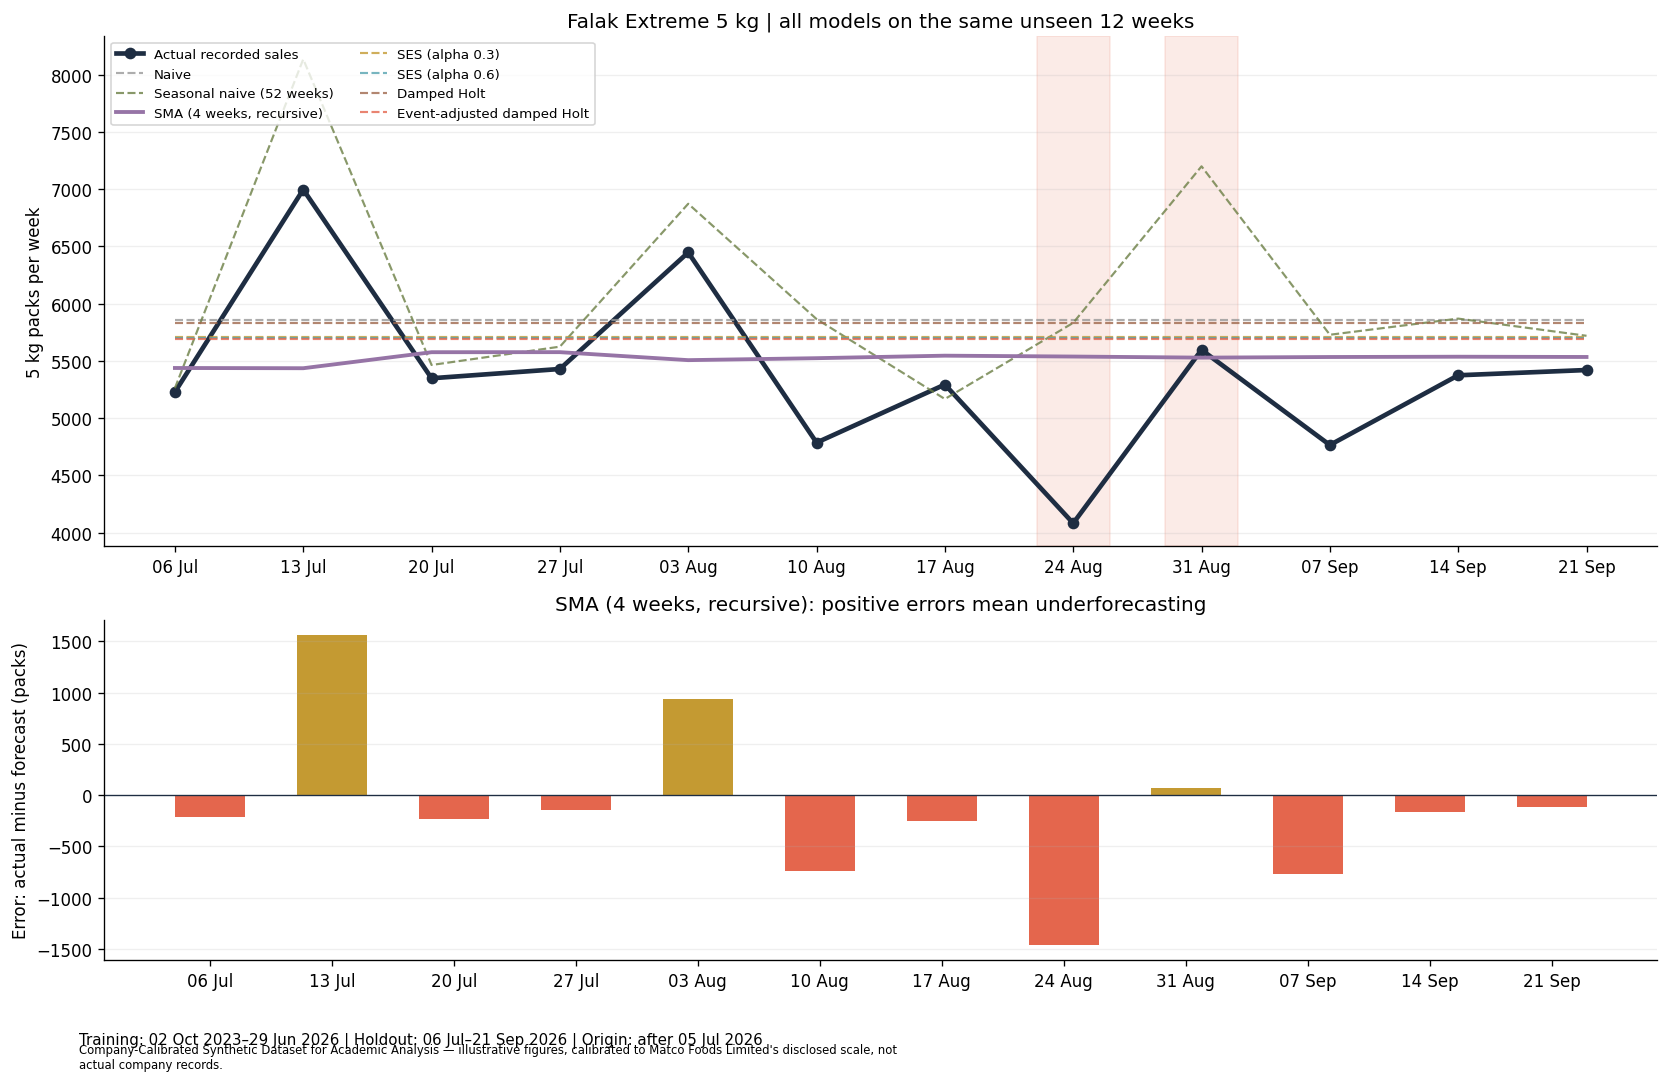

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={"height_ratios":[1.5,1]})
axes[0].plot(holdout_dates, test_df.Actual_Demand, color="#1E2D42", marker="o", linewidth=2.8, label="Actual recorded sales")
colors = ["#999999", "#6B7E44", "#9674A6", "#C49A32", "#55A3B0", "#9F684C", "#E4664D"]
for (name, f), color in zip(forecast_dict.items(), colors):
    axes[0].plot(holdout_dates, f, label=name, color=color, linewidth=2.3 if name==best_model else 1.3,
                 linestyle="-" if name==best_model else "--", alpha=1 if name==best_model else 0.8)
axes[0].set(title="Falak Extreme 5 kg | all models on the same unseen 12 weeks", ylabel="5 kg packs per week")
axes[0].legend(loc="upper left", fontsize=8, ncol=2)
for date in holdout_detail.loc[holdout_detail.Stockout_Flag.eq(1), "Week_Start_Date"]:
    axes[0].axvspan(date-pd.Timedelta(days=2), date+pd.Timedelta(days=2), color="#E4664D", alpha=0.13)
axes[1].bar(holdout_dates, holdout_detail.Error, width=4, color=["#C49A32" if e>=0 else "#E4664D" for e in holdout_detail.Error])
axes[1].axhline(0,color="#1E2D42",linewidth=0.8)
axes[1].set(ylabel="Error: actual minus forecast (packs)",title=f"{best_model}: positive errors mean underforecasting")
for ax in axes:
    ax.set_xticks(holdout_dates)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.grid(axis="y",alpha=0.2)
fig.text(0.05,0.025, "Training: 02 Oct 2023–29 Jun 2026 | Holdout: 06 Jul–21 Sep 2026 | Origin: after 05 Jul 2026",fontsize=9)
import textwrap
fig.text(0.05,0.003,"\n".join(textwrap.wrap(LABEL,145)),fontsize=7)
fig.tight_layout(rect=[0,0.06,1,1])
fig.savefig("MGT353_Forecasting_M1_MohammadOmerFarooq_Matco_Holdout.png",dpi=180,bbox_inches="tight")
plt.show()



## Provisional recommendation and managerial interpretation

The **four-week recursive moving average** is the provisional choice: MAD **553.63 packs/week**, MAPE **10.51%**, RMSE **752.68 packs**, WAPE **10.26%**, Bias **−125.48 packs/week**, RSFE **−1,505.81 packs**, Tracking Signal **−2.72**. It improves WAPE by **25.9% relative to naive**, also has the lowest RMSE, and stays within the illustrative ±4 review band. The negative bias means it overforecast on average. The total plan exceeded recorded holdout sales by about 1,506 packs, equivalent to 7.53 tonnes of rice across 12 weeks; that difference is not automatically excess inventory because sales were availability-constrained in two weeks.

The typical miss of 554 five-kilogram packs is about 2.77 tonnes per week. WAPE is total absolute error as a share of total recorded volume, not a promised service level. Promotions on July 13 and August 3 are large underforecasts; the August 24 stockout scenario is a large overforecast of constrained sales. September 7 and August 10 are ordinary tagged weeks, so unexplained variation and level mismatch remain plausible rather than certain diagnoses. Promotions and unknown operational shocks limit all level methods.

Event-adjusted Holt and SES 0.6 are close (WAPE 11.83% and 11.88%, a 0.05 percentage-point gap); that difference is too small to claim a meaningful advantage. Their negative tracking signals exceed the assumed review band. A 12-week holdout is limited, contains no calendar-event weeks, and selection uses the same holdout being reported. Do not claim it independently confirms the event adjustment or future accuracy. Driver analysis may support planned promotion adjustments, but this holdout must not be repeatedly tuned to make those adjustments look better.

**No leakage found:** forecasts use the frozen training block and known calendar only, SMA appends predicted values, and held-out actuals are used only for scoring and miss diagnosis. Errors are visibly nonzero; the source dataset was not regenerated. This is a model evaluation, not verification of actual company records.

## AI use and verification update

AI implemented and documented the seven candidates, metrics, plots and miss diagnoses using the existing Section 4.2 synthetic dataset. Verification checks the source hash, date split, baseline indexing, recursive forecasting and independently computed MAD, RMSE and WAPE. Excel reproduces all seven metrics through formulas linked to raw data and forecast values. Training parameter search, initialization and event adjustment are disclosed. These checks establish arithmetic and process consistency; they do not establish real-world demand accuracy. The original synthesis prompt remains in Excel's Prompt sheet.


In [11]:
forecast_results = {"label": LABEL, "csv_sha256": EXPECTED_SHA256,
    "training_weeks": 144, "holdout_weeks": 12, "error_convention": "Actual minus Forecast",
    "historical_metrics": historical_metrics.reset_index().to_dict(orient="records"),
    "comparison": comparison.reset_index().to_dict(orient="records"),
    "forecasts": {k: v.tolist() for k,v in forecast_dict.items()},
    "fitted_parameters": fitted_parameters, "provisional_model": best_model,
    "holdout": json.loads(holdout_detail.to_json(orient="records",date_format="iso")),
    "five_largest": json.loads(five_largest.to_json(orient="records",date_format="iso")),
    "verification": "Training-only model inputs; holdout actuals used only for scoring; independent MAD/RMSE/WAPE verified."}
Path("MGT353_Forecasting_M1_MohammadOmerFarooq_Matco_Forecast_Results.json").write_text(json.dumps(forecast_results,indent=2),encoding="utf-8")

print("Saved forecast results. All forecast and metric verification checks passed.")


Saved forecast results. All forecast and metric verification checks passed.


## Multiple regression and demand drivers: Section 10

Fit **training data only**: Demand = intercept + Price + Promo_Flag + Event_Flag + Distribution_Points. Price is the regular shelf price before discount, and demand is recorded sales in five-kilogram packs. The OLS coefficients describe associations holding the other included drivers constant.

Report ordinary OLS p-values and two robustness checks: HC3 for heterogeneous residual variance, and Newey-West HAC with a predeclared four-week lag for weekly dependence. Robust p-values use an approximate t reference with 139 residual degrees of freedom. These are model-based statistical summaries of synthetic observations, not evidence of real-world causation. Check VIF, residual dependence and sensitivity to excluding the two training stockout weeks. The primary model keeps all training weeks.


In [12]:
from scipy import stats

# SECTION 10: training-only multiple regression. No holdout inputs are used.
driver_names = ["Price", "Promo_Flag", "Event_Flag", "Distribution_Points"]
X = np.column_stack([np.ones(len(train_df)), train_df[driver_names].to_numpy(float)])
y = train_df.Actual_Demand.to_numpy(float)
coef = np.linalg.lstsq(X, y, rcond=None)[0]
fitted = X @ coef
resid = y - fitted
n, k = X.shape
dof = n - k
xtx_inv = np.linalg.inv(X.T @ X)
sse, sst = float(resid @ resid), float(np.sum((y-y.mean())**2))
r_squared = 1 - sse/sst
adjusted_r_squared = 1-(1-r_squared)*(n-1)/dof
cov_ols = (sse/dof)*xtx_inv
hat_diagonal = np.sum((X @ xtx_inv)*X, axis=1)
hc3_scores = X * (resid/(1-hat_diagonal))[:, None]
cov_hc3 = xtx_inv @ (hc3_scores.T @ hc3_scores) @ xtx_inv
# Newey-West covariance with a predeclared four-week lag and small-sample factor.
scores = X * resid[:, None]
meat = scores.T @ scores
for lag in range(1,5):
    cross = scores[lag:].T @ scores[:-lag]
    meat += (1-lag/5)*(cross + cross.T)
cov_hac = (n/dof)*xtx_inv @ meat @ xtx_inv
se_ols = np.sqrt(np.diag(cov_ols))
se_hc3 = np.sqrt(np.diag(cov_hc3))
se_hac = np.sqrt(np.diag(cov_hac))
p_ols = 2*stats.t.sf(np.abs(coef/se_ols), dof)
p_hc3 = 2*stats.t.sf(np.abs(coef/se_hc3), dof)
p_hac = 2*stats.t.sf(np.abs(coef/se_hac), dof)
critical = stats.t.ppf(0.975,dof)
coefficient_table = pd.DataFrame({"Driver":["Intercept"]+driver_names,
    "Coefficient":coef, "OLS SE":se_ols, "OLS p-value":p_ols,
    "HC3 p-value (approx.)":p_hc3, "HAC4 p-value (approx.)":p_hac,
    "HAC4 SE":se_hac, "HAC4 CI lower":coef-critical*se_hac,
    "HAC4 CI upper":coef+critical*se_hac})
vifs = {}
for j, name in enumerate(driver_names, start=1):
    other = np.delete(X,j,axis=1)
    target = X[:,j]
    auxiliary_residual = target-other @ np.linalg.lstsq(other,target,rcond=None)[0]
    auxiliary_r2 = 1-np.sum(auxiliary_residual**2)/np.sum((target-target.mean())**2)
    vifs[name] = float(1/(1-auxiliary_r2))
durbin_watson = float(np.sum(np.diff(resid)**2)/sse)
print("TRAINING regression: R²",r_squared,"Adjusted R²",adjusted_r_squared,"n",n,"residual df",dof)
print(coefficient_table.to_string(index=False,float_format=lambda x: f"{x:.6g}"))
display(pd.Series(vifs,name="VIF"))
print("Durbin-Watson residual diagnostic:",durbin_watson)

# Independent coefficient cross-check: center and scale X, solve QR system.
raw_drivers = train_df[driver_names].to_numpy(float)
centers, scales = raw_drivers.mean(axis=0), raw_drivers.std(axis=0)
scaled_X = np.column_stack([np.ones(n),(raw_drivers-centers)/scales])
q,r = np.linalg.qr(scaled_X,mode="reduced")
scaled_coef = np.linalg.solve(r,q.T@y)
independent_coef = np.r_[scaled_coef[0]-np.sum(scaled_coef[1:]*centers/scales),scaled_coef[1:]/scales]
np.testing.assert_allclose(coef,independent_coef,rtol=1e-8,atol=1e-7)
print("PASS: independent centered/scaled QR regression matches the coefficient estimates.")



TRAINING regression: R² 0.6109642746879246 Adjusted R² 0.5997690020170735 n 144 residual df 139
             Driver  Coefficient   OLS SE  OLS p-value  HC3 p-value (approx.)  HAC4 p-value (approx.)  HAC4 SE  HAC4 CI lower  HAC4 CI upper
          Intercept      1091.67  1160.42     0.348462               0.310759                0.333193  1124.18       -1131.03        3314.36
              Price    -0.718668 0.608469     0.239577               0.251626                 0.30505   0.6981       -2.09894       0.661599
         Promo_Flag      1529.81  114.705  1.20444e-26            1.96043e-17             7.44014e-21  138.004        1256.95        1802.67
         Event_Flag      701.698  124.412  9.15744e-08            5.15441e-06             1.99295e-09  109.279        485.633        917.763
Distribution_Points      5.67419  1.86329   0.00278188             0.00258641                0.004678  1.97371        1.77182        9.57657
Price                  2.904883
Promo_Flag             1.0

## Regression interpretation in business language

The estimated equation is:

**Demand = 1,091.669 − 0.7187 × Price + 1,529.811 × Promo_Flag + 701.698 × Event_Flag + 5.6742 × Distribution_Points.**

- **Price:** a PKR 100 increase is associated with about 72 fewer packs/week, holding the included drivers constant. HAC p ≈0.305 and the interval includes zero. The negative sign is plausible, but this sample does not justify a firm pricing decision.
- **Promotion:** a promotion week is associated with about 1,530 additional packs, or 7.65 tonnes, holding the other included drivers constant. HAC p <0.001. Promo_Flag averages discounts of different depths, so it does not establish the effect of a particular discount or guarantee future uplift.
- **Calendar event:** an event week is associated with about 702 additional packs, or 3.51 tonnes, under the same qualification. HAC p <0.001. Event magnitudes and overlap with promotions still vary.
- **Coverage:** another 100 distribution points are associated with about 567 additional packs/week, holding the included drivers constant. HAC p ≈0.0047. An outlet count does not tell us outlet size or customer potential.
- **Intercept:** about 1,092 packs at zero prices, zero outlets and no flags. That combination lies outside the data, so the intercept is a mathematical baseline rather than a usable operating forecast.

Training R² is **0.611** and adjusted R² **0.600**. This is explanatory fit, not holdout forecast accuracy. Price and distribution expand together, which makes their separate effects less certain (VIF about 2.9). Omitted discount depth, competitor activity, store mix and availability constraints can confound the estimates. Stockout exclusion leaves promotion association near 1,504 packs and event association near 675 packs; this is a sensitivity check, not a replacement model chosen for a better result.

**Planning implication:** coordinate promotions with packing and replenishment. An illustrative driver calculation at PKR 2,865, 1,106 outlets, Promo_Flag=1 and Event_Flag=0 gives about **6,838 packs/week**. These driver inputs are assumed, and this regression illustration is not a tested eighth forecast competitor. It motivates reserving a 7,000-pack capacity option and checking the approved campaign before committing extra supply.


In [13]:
# Honest sensitivity: omit training stockout weeks, without replacing primary model.
nonstock = train_df.Stockout_Flag.eq(0).to_numpy()
sensitivity_coef = np.linalg.lstsq(X[nonstock],y[nonstock],rcond=None)[0]
display(pd.DataFrame({"Driver":["Intercept"]+driver_names,"Primary (all training weeks)":coef,
    "Sensitivity (exclude training stockout weeks)":sensitivity_coef}))



                Driver  Primary (all training weeks)  Sensitivity (exclude training stockout weeks)
0            Intercept                   1091.668916                                     768.972280
1                Price                     -0.718668                                      -0.400503
2           Promo_Flag                   1529.810581                                    1504.002007
3           Event_Flag                    701.698239                                     675.303633
4  Distribution_Points                      5.674193                                       5.222489


## Forward planning and uncertainty

Refit the selected **four-week recursive SMA** using all 156 available historical observations only after preserving the holdout scores. This full-history refit is for the forward plan; it does not replace or improve the original holdout evaluation. No confirmed future campaign schedule is supplied. The baseline therefore carries the recent mixed-week sales level, while promotions are challenged separately in scenarios.

The 10th–90th residual envelope comes from 81 rolling 12-week forecasts entirely inside the training period. Its origins overlap and its points are dependent. It is a descriptive **pointwise empirical error envelope**, not a calibrated 80% confidence interval, simultaneous horizon range or service-level guarantee. Do not sum its endpoints to claim an 80% interval for total demand. The holdout coverage check below is retrospective and does not tune the envelope.


In [14]:
# SECTION 11 / forward planning: refit the SELECTED SMA with all available history.
# Holdout is now historical, but this does not alter its previously reported score.
future_dates = pd.date_range(df.Week_Start_Date.iloc[-1]+pd.Timedelta(days=7),periods=12,freq="7D")
future_point = recursive_sma(df.Actual_Demand.to_numpy(float),12)
# Pointwise 80% empirical error envelope from training-only rolling origins.
# Overlapping origins are dependent; this is NOT a calibrated confidence interval.
rolling_errors=[]
for origin in range(52,len(train_df)-11):
    f = recursive_sma(train_df.Actual_Demand.iloc[:origin].to_numpy(float),12)
    rolling_errors.append(train_df.Actual_Demand.iloc[origin:origin+12].to_numpy(float)-f)
rolling_errors = np.array(rolling_errors)
q10,q90 = np.quantile(rolling_errors,[0.1,0.9],axis=0)
future_table = pd.DataFrame({"Week_Start_Date":future_dates,"Forecast_Packs":future_point,
    "Envelope_Lower":np.maximum(0,future_point+q10),"Envelope_Upper":future_point+q90,
    "Forecast_Tonnes":future_point*5/1000})
holdout_envelope_coverage = float(np.mean((test_df.Actual_Demand.to_numpy() >= best_forecast+q10)&
    (test_df.Actual_Demand.to_numpy() <= best_forecast+q90)))
print("Forward 12-week total:",future_point.sum(),"packs; tonnes:",future_point.sum()*0.005)
print("Training rolling origins:",len(rolling_errors),"Holdout envelope coverage:",holdout_envelope_coverage)
display(future_table.round(2))



Forward 12-week total: 63478.02389639616 packs; tonnes: 317.39011948198083
Training rolling origins: 81 Holdout envelope coverage: 0.8333333333333334
   Week_Start_Date  Forecast_Packs  Envelope_Lower  Envelope_Upper  Forecast_Tonnes
0       2026-09-28         5289.75         4130.25         6554.75            26.45
1       2026-10-05         5212.94         4028.88         6456.38            26.06
2       2026-10-12         5324.67         4225.77         6573.34            26.62
3       2026-10-19         5312.09         4211.29         6720.24            26.56
4       2026-10-26         5284.86         4190.89         6886.88            26.42
5       2026-11-02         5283.64         4160.11         6646.24            26.42
6       2026-11-09         5301.32         4034.05         6704.84            26.51
7       2026-11-16         5295.48         4158.02         6957.28            26.48
8       2026-11-23         5291.32         4421.18         7054.96            26.46
9       20

## Stress-test the supply decision: Section 11

Operational inputs are **documented academic assumptions**, not company records: regular capacity 6,000 packs/week; reserved option 7,000; opening/target buffer 2,500 packs; replenishment lead time one week; first two weeks firm; remaining ten weeks adjustable; assumed finished-pack cost PKR 2,400. The buffer therefore ties up an illustrative PKR 6 million. If opening stock is unavailable, establish it before applying this plan.

After the firm period, receipts react to the **previous week's demand**, target buffer and current inventory, bounded by capacity. Scenarios do not assume perfect foresight. Shortages are unfilled volume with no backorders carried forward; they become lost sales only if customers do not wait. A delivery interruption sets week-three receipts to zero and later receipts are replanned within weekly capacity; no separate overdue batch is automatically added.

Test demand ±10% and ±20%, a 30% two-week promotion shock in weeks 3–4, and a one-week delivery interruption in week 3. Compare regular and reserved capacity; report shortage, ending/peak inventory and illustrative working capital. One pack = 0.005 tonnes. Financial values use assumed unit cost, not retail selling price.


In [15]:
# Operational assumptions: academic inputs, not actual Matco capacities or costs.
capacity_regular=6000
capacity_option=7000
initial_buffer=2500
lead_time_weeks=1
firm_weeks=2
unit_cost_assumed=2400 # assumed cost per finished 5 kg pack, NOT the retail price
weekly_base_plan = np.ceil(future_point).astype(int)
firm_commitment = int(weekly_base_plan[:firm_weeks].sum())
flexible_expected = int(weekly_base_plan[firm_weeks:].sum())

def simulate_plan(demand, capacity=capacity_regular, delay_week=None):
    # First two weeks are firm. Later receipts react to LAST week's demand.
    # No assumption of perfect foresight; orders arrive one week after review.
    opening = float(initial_buffer)
    rows=[]
    for i, current_demand in enumerate(demand):
        if i < firm_weeks:
            receipt=float(weekly_base_plan[i])
        else:
            desired = float(demand[i-1])+initial_buffer-opening
            receipt=float(min(capacity,max(0,np.ceil(desired))))
        if delay_week is not None and i==delay_week:
            receipt=0.0
        available=opening+receipt
        shortage=max(0,float(current_demand)-available)
        ending=max(0,available-float(current_demand))
        rows.append({"Week":i+1,"Demand":float(current_demand),"Opening":opening,
                     "Receipt":receipt,"Shortage":shortage,"Ending":ending})
        opening=ending
    return pd.DataFrame(rows)

scenario_demands={"Base":future_point.copy(),"Downside 10%":future_point*.9,
    "Downside 20%":future_point*.8,"Upside 10%":future_point*1.1,"Upside 20%":future_point*1.2}
promotion_shock=future_point.copy();promotion_shock[2:4]*=1.3
scenario_demands["Promotion shock +30% (weeks 3–4)"]=promotion_shock
scenario_demands["Delivery interruption (week 3)"]=future_point.copy()
scenario_rows=[];scenario_detail={}
for name,demand in scenario_demands.items():
    delay=2 if name.startswith("Delivery") else None
    regular=simulate_plan(demand,capacity_regular,delay)
    option=simulate_plan(demand,capacity_option,delay)
    scenario_detail[name]={"regular":regular.to_dict(orient="records"),"option":option.to_dict(orient="records")}
    scenario_rows.append({"Scenario":name,"Demand_Packs":float(np.sum(demand)),
        "Demand_Tonnes":float(np.sum(demand)*.005),"Regular_Receipts":float(regular.Receipt.sum()),
        "Regular_Shortage":float(regular.Shortage.sum()),"Option_Shortage":float(option.Shortage.sum()),
        "Regular_Ending_Stock":float(regular.Ending.iloc[-1]),
        "Peak_Stock":float(max(initial_buffer,regular.Ending.max())),
        "Peak_Stock_Cost_PKR":float(max(initial_buffer,regular.Ending.max())*unit_cost_assumed),
        "First_Shortage_Week":int(regular.loc[regular.Shortage.gt(0),"Week"].iloc[0]) if regular.Shortage.gt(0).any() else 0})
scenario_table=pd.DataFrame(scenario_rows)
display(scenario_table.round(2))
print("Firm first-two-week receipts:",firm_commitment,"packs; later adjustable base receipts:",flexible_expected)
print("Buffer value (assumed cost): PKR",initial_buffer*unit_cost_assumed)

# Production conservation check, every week and scenario, both capacity settings.
for name,details in scenario_detail.items():
    for variant,rows in details.items():
        for row in rows:
            np.testing.assert_allclose(row["Opening"]+row["Receipt"]+row["Shortage"]-row["Demand"],row["Ending"],atol=1e-8)
            assert min(row["Opening"],row["Receipt"],row["Shortage"],row["Ending"])>=0
print("PASS: every inventory roll-forward and scenario conservation identity.")



                           Scenario  Demand_Packs  Demand_Tonnes  Regular_Receipts  Regular_Shortage  Option_Shortage  Regular_Ending_Stock  Peak_Stock  Peak_Stock_Cost_PKR  First_Shortage_Week
0                              Base      63478.02         317.39           63480.0              0.00             0.00               2501.98     2527.69           6066452.34                    0
1                      Downside 10%      57130.22         285.65           57132.0              0.00             0.00               2501.78     3550.58           8521395.00                    0
2                      Downside 20%      50782.42         253.91           50784.0              0.00             0.00               2501.58     4600.85          11042040.00                    0
3                        Upside 10%      69825.83         349.13           69828.0              0.00             0.00               2502.17     2505.32           6012777.45                    0
4                        Upsid

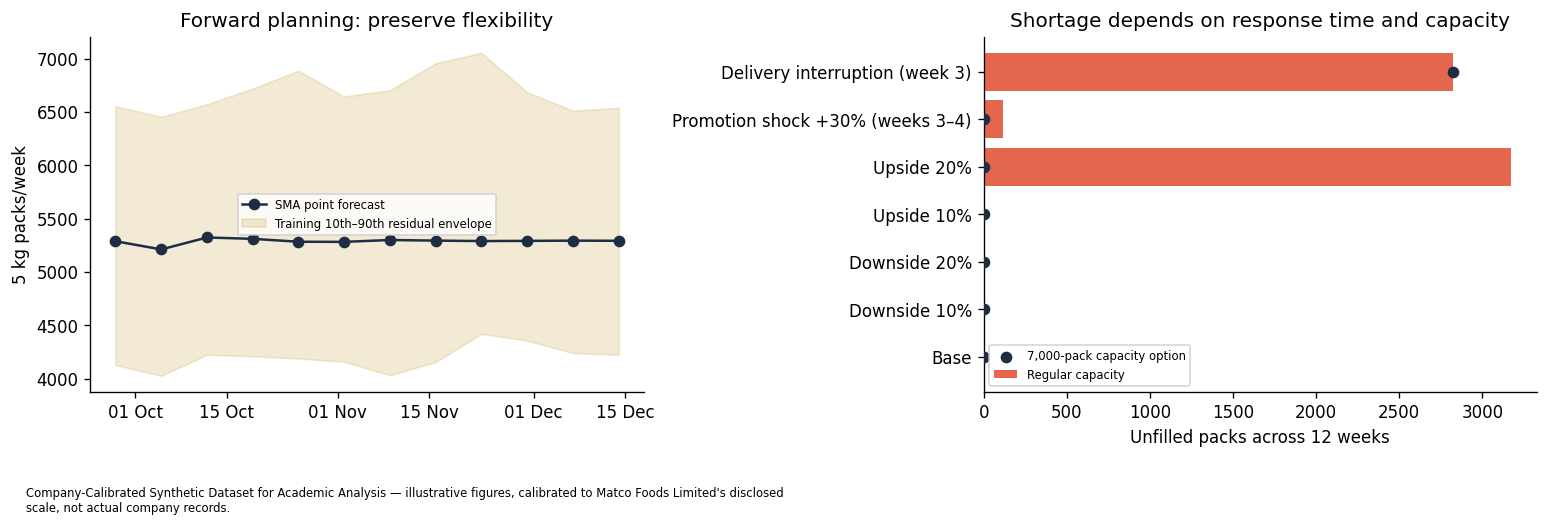

In [16]:
fig,axes=plt.subplots(1,2,figsize=(13,4.4))
axes[0].plot(future_dates,future_point,color="#1E2D42",marker="o",label="SMA point forecast")
axes[0].fill_between(future_dates,future_table.Envelope_Lower,future_table.Envelope_Upper,color="#C49A32",alpha=.2,label="Training 10th–90th residual envelope")
axes[0].set(title="Forward planning: preserve flexibility",ylabel="5 kg packs/week")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"));axes[0].legend(fontsize=7)
axes[1].barh(scenario_table.Scenario,scenario_table.Regular_Shortage,color="#E4664D",label="Regular capacity")
axes[1].scatter(scenario_table.Option_Shortage,scenario_table.Scenario,color="#1E2D42",label="7,000-pack capacity option",zorder=3)
axes[1].set(title="Shortage depends on response time and capacity",xlabel="Unfilled packs across 12 weeks");axes[1].legend(fontsize=7)
fig.tight_layout(rect=[0,.11,1,1]);fig.text(.02,.015,"\n".join(textwrap.wrap(LABEL,130)),fontsize=7)
fig.savefig("Forward_and_Stress.png",dpi=180,bbox_inches="tight");plt.show()



## Quantified recommendation, owner and review trigger

The baseline predicts **63,478 packs**, about **317.39 tonnes**, across 12 weeks. Rounded weekly planning quantities total **63,483 packs**. Make **10,503 packs** firm for the first two weeks, and retain **52,980 packs** of baseline packing volume over the remaining ten weeks as adjustable. The dynamic replenishment simulation may differ by a few packs from the rounded weekly forecast because it also responds to inventory.

Use a **2,500-pack / 12.5-tonne opening buffer** and confirm **6,000-pack weekly regular capacity**. Reserve a further **1,000 packs/week** as an option rather than immediately producing it. The +20% scenario causes about **3,171 unfilled packs** at regular capacity; the 7,000-pack option eliminates modeled shortage under the stated response assumptions. The two-week promotion shock leaves about **114 unfilled packs** at regular capacity and none with the option. A week-three delivery interruption causes about **2,824 unfilled packs** even with the capacity option, so a backup delivery route or alternative available stock is needed. The −20% case temporarily raises inventory to about **4,601 packs**, with illustrative peak cost **PKR 11.04 million**, before later receipts are reduced.

**Owner:** Head of Supply Chain approves commitment and capacity reservation; Demand Planning reviews weekly; Sales confirms promotions; Operations and Procurement confirm stock, lead time and backup deliveries. This is a proposed academic responsibility assignment.

**Review every week.** Reforecast if two consecutive weeks' combined actuals differ from their combined forecast by more than 10% in absolute terms; if rolling eight-week Tracking Signal falls outside the assumed ±4 band; if an approved campaign projects over 6,000 packs/week; or if confirmed receipts are delayed or stockouts occur. For the first review, the two-week test applies after both weeks close. Use Error = Actual − Forecast throughout. Activate reserved capacity before a confirmed promotion or sustained uplift exceeds regular capacity. If the option is unavailable, revise campaign volume or allocation rather than assume the gap can be served.

## Final verification and limitations

The source hash, date ordering, 144/12 split, no-holdout recursion, common forecast origin, baseline indices, independent metric arithmetic, regression QR check and inventory conservation assertions execute in this notebook. The dataset workbook independently calculates three holdout metrics using Excel formulas. This checks arithmetic and design; synthetic demand and assumed operational inputs do not demonstrate actual company accuracy or capacity. The 12-week holdout contains no calendar-event weeks, and the selected model has not been evaluated on a second untouched holdout. Keep that qualification in the dashboard and memo.


In [17]:
final_results={"label":LABEL,"csv_sha256":EXPECTED_SHA256,
    "regression":{"n":n,"residual_df":dof,"r_squared":r_squared,"adjusted_r_squared":adjusted_r_squared,
        "coefficients":coefficient_table.to_dict(orient="records"),"vif":vifs,"durbin_watson":durbin_watson,
        "price_outlet_correlation":float(train_df.Price.corr(train_df.Distribution_Points)),
        "stockout_exclusion_coefficients":sensitivity_coef.tolist()},
    "future":json.loads(future_table.to_json(orient="records",date_format="iso")),
    "future_total":float(future_point.sum()),"firm_commitment":firm_commitment,"flexible_expected":flexible_expected,
    "planning":{"capacity_regular":capacity_regular,"capacity_option":capacity_option,
        "initial_buffer":initial_buffer,"lead_time_weeks":lead_time_weeks,"firm_weeks":firm_weeks,
        "unit_cost_assumed":unit_cost_assumed,"base_plan_total":int(weekly_base_plan.sum()),
        "rolling_origins":len(rolling_errors),"holdout_envelope_coverage":holdout_envelope_coverage},
    "scenarios":scenario_table.to_dict(orient="records"),"scenario_detail":scenario_detail,
    "training_envelope":{"q10":q10.tolist(),"q90":q90.tolist()},
    "historical_rows":json.loads(df.iloc[:,:14].to_json(orient="records",date_format="iso")),
    "forecast_results":forecast_results,
    "diagnosis":diagnosis}
Path("Final_Results.json").write_text(json.dumps(final_results,indent=2),encoding="utf-8")
print("Complete analysis saved. Regression and planning assumptions are explicitly separated from actual company records.")


Complete analysis saved. Regression and planning assumptions are explicitly separated from actual company records.
